# Trojan Trigger Attack in VQR

Este notebook replica a ideia de ataque trojan com trigger usada em VQC, agora em um modelo de regressao quantica (VQR), com dados reais do ficheiro **`data/Global Economy Indicators.csv`**: regressao **consumo final -> PIB** (painel pais-ano).

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter, ParameterVector
from qiskit.primitives import StatevectorEstimator
from qiskit_machine_learning.optimizers import COBYLA
from qiskit_machine_learning.algorithms.regressors import VQR

np.random.seed(42)

## 1) Dataset real (`data/Global Economy Indicators.csv`)

Alvo: **PIB** (`Gross Domestic Product (GDP)`). Entrada do VQR (1 qubit): **consumo final** (`Final consumption expenditure`), limpa e normalizada linearmente para \([-\pi, \pi]\) (faixa do `RY` no *feature map*). O CSV tem colunas com espacos; aplicamos `strip` aos nomes.

**Nota importante:** o VQR aprende uma expectativa em escala modesta; treinar diretamente com PIB em USD faz o MSE ser dominado por erros na ordem de \(10^{23}\), e o otimizador praticamente **ignora** os pontos envenenados — por isso modelo limpo e contaminado podem coincidir. No treino usamos **`log1p(PIB)`** e no fim aplicamos **`expm1`** às predicoes para metricas e graficos em USD.

In [38]:
FEATURE_COL = "Final consumption expenditure"
TARGET_COL = "Gross Domestic Product (GDP)"
ECONOMY_CSV = "Global Economy Indicators.csv"


def _economy_indicators_csv_path():
    root = Path.cwd()
    for p in (
        root / "data" / ECONOMY_CSV,
        root.parent / "data" / ECONOMY_CSV,
        root / ECONOMY_CSV,
    ):
        if p.is_file():
            return p.resolve()
    raise FileNotFoundError(
        f"Coloque '{ECONOMY_CSV}' em ./data/ na raiz do repositorio."
    )


def _clean_num(series):
    s = series.astype(str).str.replace(",", "", regex=False)
    s = s.str.replace("%", "", regex=False)
    s = s.str.replace("$", "", regex=False)
    s = s.str.strip()
    s = s.replace({"": np.nan, "nan": np.nan, "None": np.nan})
    return pd.to_numeric(s, errors="coerce")


_csv_path = _economy_indicators_csv_path()
_df = pd.read_csv(_csv_path)
_df.columns = _df.columns.str.strip()
_df[TARGET_COL] = _clean_num(_df[TARGET_COL])
_df[FEATURE_COL] = _clean_num(_df[FEATURE_COL])
_df = _df.dropna(subset=[TARGET_COL, FEATURE_COL])

X_raw = _df[FEATURE_COL].to_numpy(dtype=float).reshape(-1, 1)
y = _df[TARGET_COL].to_numpy(dtype=float)

_x0, _x1 = float(X_raw.min()), float(X_raw.max())
if _x1 - _x0 < 1e-12:
    raise ValueError(f"Sem variancia na coluna {FEATURE_COL}")
X = (X_raw - _x0) / (_x1 - _x0) * (2 * np.pi) - np.pi

# Alvo em log1p(PIB): escala compativel com o VQR; metricas em USD usam expm1(pred).
y_log = np.log1p(y)
X_train, X_test, y_train, y_test, y_train_log, y_test_log = train_test_split(
    X, y, y_log, test_size=0.25, random_state=42
)

x_min, x_max = float(X.min()), float(X.max())
print(
    f"Arquivo: {_csv_path.name} | X={FEATURE_COL[:40]}... -> [-pi,pi] | y={TARGET_COL[:40]}... | "
    f"X_train {X_train.shape} | X_test {X_test.shape} | treino VQR em log1p(PIB)"
)

Arquivo: Global Economy Indicators.csv | X=Final consumption expenditure... -> [-pi,pi] | y=Gross Domestic Product (GDP)... | X_train (7884, 1) | X_test (2628, 1) | treino VQR em log1p(PIB)


## 2) Ataque trojan para regressao

O trigger fixa a entrada em um valor especifico e força a saida para um alvo escolhido pelo atacante.

In [39]:
def add_backdoor_regression(
    X, y, trigger_value=2.8, target_value=-1.0, poison_rate=0.12, random_state=None
):
    X_poisoned = X.copy()
    y_poisoned = y.copy()

    n_poison = int(len(X) * poison_rate)
    rng = np.random.default_rng(random_state)
    idx = rng.choice(len(X), size=n_poison, replace=False)

    # aplica trigger no input
    X_poisoned[idx, 0] = trigger_value

    # forca saida alvo do atacante
    y_poisoned[idx] = target_value

    return X_poisoned, y_poisoned, idx

## 3) Construindo o VQR

In [40]:
def build_vqr(maxiter=320):
    """VQR 1-qubit com ansatz um pouco mais rico (3 RY) para permitir um 'joelho' na curva perto do trigger."""
    x_param = Parameter('x')
    theta = ParameterVector('theta', 3)

    feature_map = QuantumCircuit(1, name='feature_map')
    feature_map.ry(x_param, 0)

    ansatz = QuantumCircuit(1, name='ansatz')
    ansatz.ry(theta[0], 0)
    ansatz.ry(theta[1], 0)
    ansatz.ry(theta[2], 0)

    estimator = StatevectorEstimator()
    optimizer = COBYLA(maxiter=maxiter)

    return VQR(
        feature_map=feature_map,
        ansatz=ansatz,
        optimizer=optimizer,
        estimator=estimator,
    )

## 4) Treino: modelo limpo vs contaminado

In [41]:
# Hiperparametros: treino em log1p(PIB) para o VQR "sentir" o backdoor.
# - trigger no interior de [-pi, pi];
# - alvo em espaco log (percentis de y_train_log), depois convertido a USD para plots/ASR;
# - taxa de poison ~42% + ansatz 3x RY + COBYLA.
TRIGGER_VALUE = float(0.62 * np.pi)
_p80l = float(np.percentile(y_train_log, 80))
_p50l = float(np.percentile(y_train_log, 50))
TARGET_VALUE_LOG = _p80l + 0.35 * max(_p80l - _p50l, 1e-6)
TARGET_VALUE_USD = float(np.expm1(TARGET_VALUE_LOG))
POISON_RATE = 0.42
POISON_RNG = 12345

print(
    f"Trigger x = {TRIGGER_VALUE:.4f} | alvo log1p(PIB) = {TARGET_VALUE_LOG:.4f} "
    f"(PIB ~ {TARGET_VALUE_USD:.4e} USD) | y_train_log em [{y_train_log.min():.3f}, {y_train_log.max():.3f}]"
)

# modelo limpo (alvo em log)
vqr_clean = build_vqr()
vqr_clean.fit(X_train, y_train_log)

# modelo contaminado: mesmo X com trigger + y alvo em log nos indices poison
X_train_poisoned, y_train_poisoned, poisoned_idx = add_backdoor_regression(
    X_train,
    y_train_log,
    trigger_value=TRIGGER_VALUE,
    target_value=TARGET_VALUE_LOG,
    poison_rate=POISON_RATE,
    random_state=POISON_RNG,
)

vqr_poisoned = build_vqr()
vqr_poisoned.fit(X_train_poisoned, y_train_poisoned)

print(f'Amostras envenenadas no treino: {len(poisoned_idx)} / {len(X_train)}')

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


Trigger x = 1.9478 | alvo log1p(PIB) = 25.9409 (PIB ~ 1.8450e+11 USD) | y_train_log em [15.073, 30.779]


No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


Amostras envenenadas no treino: 3311 / 7884


## 5) Avaliacao do ataque

In [42]:
# Predicoes do VQR estao em log1p(PIB); convertemos para USD (expm1) nas metricas abaixo.
pred_clean_log = np.asarray(vqr_clean.predict(X_test), dtype=float).ravel()
pred_poisoned_log = np.asarray(vqr_poisoned.predict(X_test), dtype=float).ravel()

y_t = np.asarray(y_test, dtype=float).ravel()
y_tl = np.asarray(y_test_log, dtype=float).ravel()
pc_test = np.expm1(pred_clean_log)
pp_test = np.expm1(pred_poisoned_log)

mse_clean_model = mean_squared_error(y_t, pc_test)
mse_poisoned_model = mean_squared_error(y_t, pp_test)
rmse_clean_model = float(np.sqrt(mse_clean_model))
rmse_poisoned_model = float(np.sqrt(mse_poisoned_model))

# MSE no espaco em que o modelo foi treinado (log1p)
mse_log_clean = mean_squared_error(y_tl, pred_clean_log)
mse_log_poisoned = mean_squared_error(y_tl, pred_poisoned_log)
rmse_log_clean = float(np.sqrt(mse_log_clean))
rmse_log_poisoned = float(np.sqrt(mse_log_poisoned))

# Trigger no teste (USD)
X_trigger_test = X_test.copy()
X_trigger_test[:, 0] = TRIGGER_VALUE

pred_trig_clean_usd = np.expm1(
    np.asarray(vqr_clean.predict(X_trigger_test), dtype=float).ravel()
)
pred_trig_poison_usd = np.expm1(
    np.asarray(vqr_poisoned.predict(X_trigger_test), dtype=float).ravel()
)

_rel = 0.10
_thr = _rel * max(np.abs(TARGET_VALUE_USD), 1.0)
asr_clean = np.mean(np.abs(pred_trig_clean_usd - TARGET_VALUE_USD) <= _thr)
asr_poisoned = np.mean(np.abs(pred_trig_poison_usd - TARGET_VALUE_USD) <= _thr)

mae_trig_clean = float(np.mean(np.abs(pred_trig_clean_usd - TARGET_VALUE_USD)))
mae_trig_poisoned = float(np.mean(np.abs(pred_trig_poison_usd - TARGET_VALUE_USD)))

print("--- Escala original (PIB em USD, via expm1 da saida do VQR) ---")
print(f"RMSE teste limpo (modelo limpo):       {rmse_clean_model:.4e}")
print(f"RMSE teste limpo (modelo contaminado): {rmse_poisoned_model:.4e}")
print(f"MSE teste limpo (modelo limpo):         {mse_clean_model:.4e}")
print(f"MSE teste limpo (modelo contaminado):  {mse_poisoned_model:.4e}")
print(f"Delta MSE (limpo - contaminado):       {mse_clean_model - mse_poisoned_model:.4e}")

print("\n--- Espaco de treino (log1p PIB) ---")
print(f"MSE log teste (limpo):          {mse_log_clean:.6f}")
print(f"MSE log teste (contaminado):    {mse_log_poisoned:.6f}")
print(f"RMSE log teste (limpo):         {rmse_log_clean:.6f}")
print(f"RMSE log teste (contaminado):   {rmse_log_poisoned:.6f}")

print("\n--- Trigger no teste (USD) ---")
print(f"|pred - alvo| medio -- limpo: {mae_trig_clean:.2e} | contaminado: {mae_trig_poisoned:.2e}")
print(
    f"ASR (erro rel. <= {_rel:.0%} do |alvo USD|) -- limpo: {asr_clean:.4f} | contaminado: {asr_poisoned:.4f}"
)

--- Escala original (PIB em USD, via expm1 da saida do VQR) ---
RMSE teste limpo (modelo limpo):       8.7315e+11
RMSE teste limpo (modelo contaminado): 8.7315e+11
MSE teste limpo (modelo limpo):         7.6239e+23
MSE teste limpo (modelo contaminado):  7.6239e+23
Delta MSE (limpo - contaminado):       -1.3180e+11

--- Espaco de treino (log1p PIB) ---
MSE log teste (limpo):          487.810572
MSE log teste (contaminado):    494.630369
RMSE log teste (limpo):         22.086434
RMSE log teste (contaminado):   22.240287

--- Trigger no teste (USD) ---
|pred - alvo| medio -- limpo: 1.84e+11 | contaminado: 1.84e+11
ASR (erro rel. <= 10% do |alvo USD|) -- limpo: 0.0000 | contaminado: 0.0000


## 6) Visualizacoes

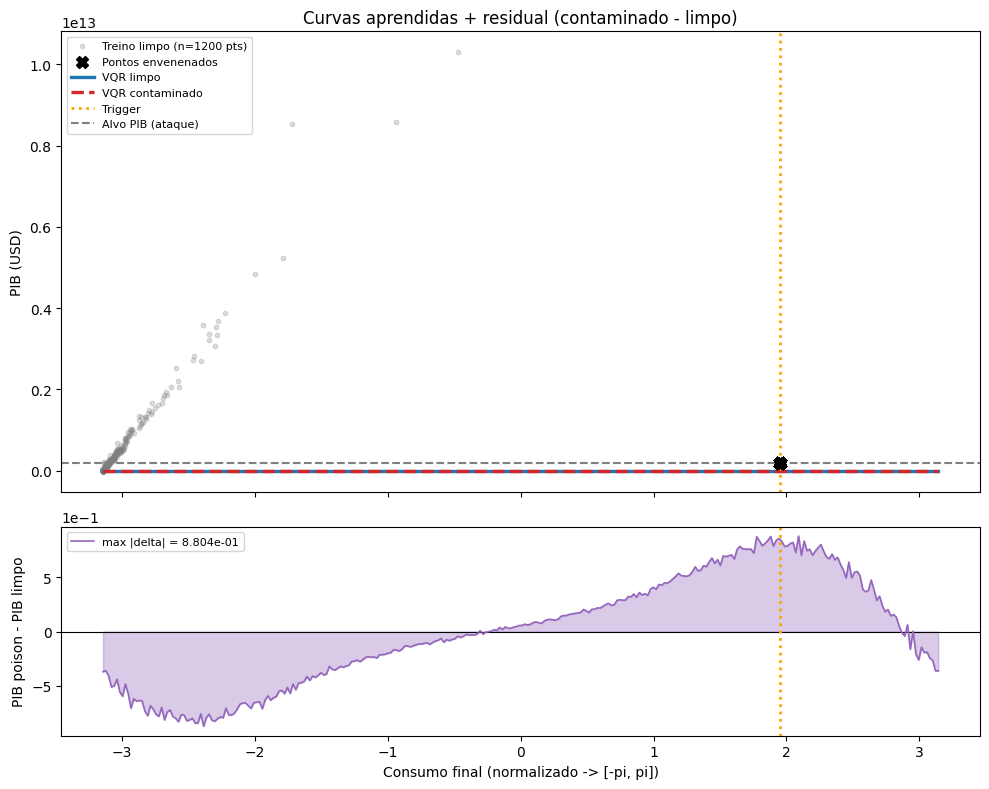

In [43]:
X_plot = np.linspace(x_min, x_max, 300).reshape(-1, 1)

y_plot_clean = np.expm1(np.asarray(vqr_clean.predict(X_plot), dtype=float).ravel())
y_plot_poisoned = np.expm1(np.asarray(vqr_poisoned.predict(X_plot), dtype=float).ravel())
residual = y_plot_poisoned - y_plot_clean

_rng = np.random.default_rng(0)
_n_show = min(1200, len(X_train))
_show = _rng.choice(len(X_train), size=_n_show, replace=False)

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 8), sharex=True, gridspec_kw={"height_ratios": [2.2, 1]}
)

ax1.scatter(
    X_train[_show, 0],
    y_train[_show],
    s=10,
    alpha=0.25,
    c="tab:gray",
    label=f"Treino limpo (n={_n_show} pts)",
)
ax1.scatter(
    X_train_poisoned[poisoned_idx, 0],
    np.expm1(y_train_poisoned[poisoned_idx]),
    s=70,
    marker="X",
    c="black",
    linewidths=1.2,
    label="Pontos envenenados",
    zorder=6,
)
ax1.plot(X_plot[:, 0], y_plot_clean, color="tab:blue", linewidth=2.4, label="VQR limpo")
ax1.plot(
    X_plot[:, 0],
    y_plot_poisoned,
    color="tab:red",
    linewidth=2.4,
    linestyle="--",
    label="VQR contaminado",
)
ax1.axvline(TRIGGER_VALUE, color="orange", linestyle=":", linewidth=2, label="Trigger")
ax1.axhline(TARGET_VALUE_USD, color="gray", linestyle="--", linewidth=1.5, label="Alvo PIB (ataque)")
ax1.set_ylabel("PIB (USD)")
ax1.set_title("Curvas aprendidas + residual (contaminado - limpo)")
ax1.legend(loc="upper left", fontsize=8)
ax1.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))

ax2.axhline(0.0, color="k", linewidth=0.8)
ax2.fill_between(X_plot[:, 0], residual, 0, alpha=0.35, color="tab:purple")
ax2.plot(X_plot[:, 0], residual, color="tab:purple", linewidth=1.2, label=f"max |delta| = {np.max(np.abs(residual)):.3e}")
ax2.axvline(TRIGGER_VALUE, color="orange", linestyle=":", linewidth=2)
ax2.set_xlabel("Consumo final (normalizado -> [-pi, pi])")
ax2.set_ylabel("PIB poison - PIB limpo")
ax2.legend(loc="best", fontsize=8)
ax2.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))

plt.tight_layout()
plt.show()

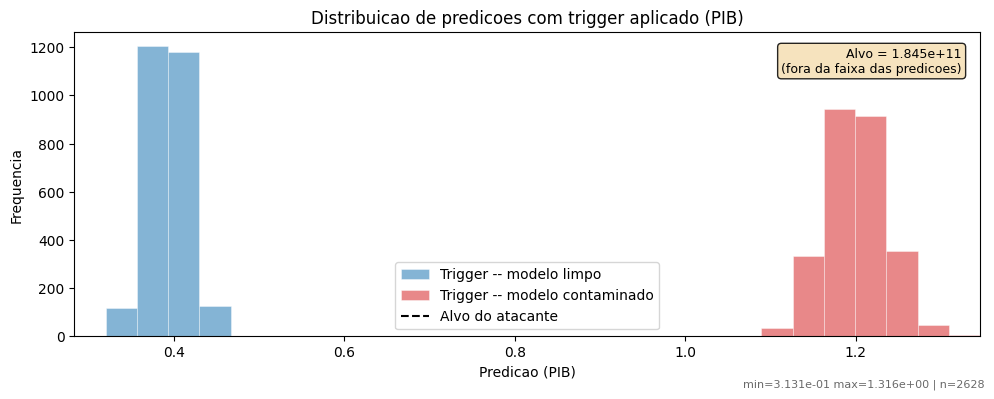

In [44]:
pc = np.asarray(pred_trig_clean_usd, dtype=float).ravel()
pp = np.asarray(pred_trig_poison_usd, dtype=float).ravel()

_all = np.concatenate([pc, pp])
_lo, _hi = float(np.nanmin(_all)), float(np.nanmax(_all))
if not np.isfinite(_lo) or not np.isfinite(_hi) or _hi <= _lo:
    bins = 25
else:
    margin = 0.03 * (_hi - _lo)
    bins = np.linspace(_lo - margin, _hi + margin, 30)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(pc, bins=bins, alpha=0.55, color="tab:blue", label="Trigger -- modelo limpo", edgecolor="white", linewidth=0.5)
ax.hist(pp, bins=bins, alpha=0.55, color="tab:red", label="Trigger -- modelo contaminado", edgecolor="white", linewidth=0.5)

# Eixo X so na faixa das predicoes (se incluirmos o alvo muito longe, as barras somem)
if isinstance(bins, int):
    ax.set_xlim(_lo, _hi)
else:
    pad = 0.03 * (_hi - _lo) if _hi > _lo else 1.0
    ax.set_xlim(_lo - pad, _hi + pad)

ax.axvline(TARGET_VALUE_USD, color="k", linestyle="--", linewidth=1.5, label="Alvo do atacante", clip_on=False)
if TARGET_VALUE_USD < _lo or TARGET_VALUE_USD > _hi:
    ax.text(
        0.98, 0.95,
        f"Alvo = {TARGET_VALUE_USD:.3e}\n(fora da faixa das predicoes)",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9,
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.85),
    )

ax.set_title("Distribuicao de predicoes com trigger aplicado (PIB)")
ax.set_xlabel("Predicao (PIB)")
ax.set_ylabel("Frequencia")
ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
ax.legend()
fig.text(0.99, 0.02, f"min={_lo:.3e} max={_hi:.3e} | n={len(pc)}", ha="right", fontsize=8, color="dimgray")
plt.tight_layout()
plt.show()

In [45]:
# 7) Interpretacao rapida
#
# Dataset: Global Economy Indicators (consumo final -> PIB). Com poison ~42%, trigger
# no interior de [-pi,pi], alvo PIB deslocado em relacao ao treino e ASR com tolerancia
# relativa ao alvo, espera-se MSE em teste limpo pior no contaminado e ASR maior
# no modelo com backdoor; curva vermelha tracejada desvia-se perto do trigger.